Comparison of thermodynamics of **NaCl** dissolved in two solvents: **water** and **methanol**.

For water, I use the Pitzer model.

For methanol, I use extended Debye Huckel formula since not much data are available.

Process:

1. For salt molality $m$ (mol/kg), calculate the activity coefficients using model. Specifically, calculate the mean activity coefficient $\gamma^\pm$ since that is all we need and all we can observe.
2. Convert the $\gamma^\pm$ into chemical potential $\mu_{\mathrm{NaCl}} = \mu_0 + 2RT\ln(\gamma^\pm m)$,
3. Fix the $\mu_0$ value in each case so that $\mu_{\mathrm{NaCl(solute)}} = \mu_{\mathrm{NaCl(pure)}}$ at the expected saturation point.
4. And in fact we do everything in terms of this species voltage difference: $$V_{\mathrm{Na}^+} - V_{\mathrm{Cl}^-}= \tfrac{1}{F}(\tilde\mu_{\mathrm{Na}^+} - \tilde\mu_{\mathrm{Cl}^-}) = \tfrac{1}{F} \mu_{\mathrm{NaCl}} = V_0 + \tfrac{RT}{F} \ln(\gamma^\pm m) $$


Methanol estimated A_e=3.886, Ba=3.098
Water V0 = -4.0809 V
           -4.0746 V expected
 MeOH V0 = -3.8687 V


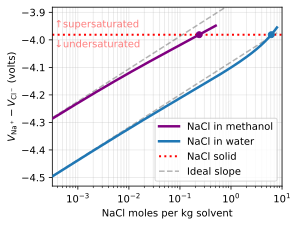

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'svg.hashsalt': 'esbd'})

# Constants
R = 8.314
T = 298.15
F = 96485.0
RT_F = (R * T) / F

# --- Pitzer Model Functions ---
def calc_gamma_pitzer(m_salt, beta0=0.0765, beta1=0.2664, Cphi=0.00127):
    """
    Calculates ln(gamma_pm) for 1-1 salt using the Pitzer model.
    """
    # These parameters for water only
    A_phi=0.392
    b = 1.2
    alpha = 2.0

    # For 1:1 salts, I = m_total.
    I = m_salt
    sqrt_I = np.sqrt(I)

    # Pitzer form for ln_gamma
    f_gamma = -A_phi * ( (sqrt_I / (1 + b * sqrt_I)) + (2/b) * np.log(1 + b * sqrt_I) )

    x = alpha * sqrt_I
    g_x = 2 * (1 - (1 + x) * np.exp(-x)) / (x**2)
    B_gamma = 2 * beta0 + 2 * beta1 * g_x # Simplified for 1:1 single salt

    C_gamma = 3/2 * Cphi

    return f_gamma + m_salt * B_gamma + m_salt**2 * C_gamma

def calc_gamma_dh(m_salt, A_e=1.176, Ba=3.29):
    """
    Calculates ln(gamma_pm) for 1-1 salt using the Debye Huckel extended law.

    A_e and Ba are molal, (kg/mol)^(1/2) units
    water A_e = 1.176 and Ba = 3.29

    A_e prop to epsilon^-1.5 * density^0.5
    B prop to epsilon^-0.5 * density^0.5
    a is solute nearest approach distance
    """
    I = m_salt
    sqrt_I = np.sqrt(I)
    return -A_e * sqrt_I / (1.0 + Ba * sqrt_I)

## Thermodynamic info

# Pitzer params for NaCl in water
params_nacl = {'beta0': 0.0765, 'beta1': 0.2664, 'Cphi': 0.00127}

# Reasonable guesses for methanol (MeOH) DH parameters.
# Dielectric constant    eps_water/eps_meoh = 78/33 = 2.4
# Density                rho_meoh/rho_water = 0.79/0.997 = 0.79
# Nearest-approach dist  a_meoh/a_water ~= 1.5  (0.6 nm vs 0.4 nm)
# A_e(water) = 1.176     (note this is 3x of pitzer A_phi)
A_e_meoh = 1.176 * (2.4)**1.5 * (0.79)**0.5
# Ba of NaCl in water = 1.5
Ba_meoh = 1.5 * (2.4)**0.5 * (0.79)**0.5 * (1.5)**1.0
print(f"Methanol estimated A_e={A_e_meoh:.3f}, Ba={Ba_meoh:.3f}")

# Saturation Limits (Solubility)
m_sat_water = 6.15  # mol/kg
m_sat_meoh  = 0.238 # mol/kg (e.g. Li et al, 2010)
# V_Na+ - V_Cl- for solid NaCl (i.e. saturation)
V_solid = -3.9813


## Helpers

# Calculate V_Na+ - V_Cl- from ln_gammas
def calc_V(V0, m_array, ln_gammas):
    return V0 + 2*RT_F * (ln_gammas + np.log(m_array))

# Converts ln_gammas to V trace, making sure it intercepts saturation
# at the expected molality.
def calc_V_sat(m_sat, m_array, ln_gammas):
    raw_V_array = calc_V(0, m_array, ln_gammas)
    raw_V_sat = np.interp(m_sat, m_array, raw_V_array)
    V0 = V_solid - raw_V_sat
    return V0, V0 + raw_V_array


## Generate traces

m_range = np.logspace(-3.5, 0.9, 500) # For Water
m_range_meoh = np.logspace(-3.5, -0.3, 400) # Stop earlier for MeOH

ln_gamma_water = calc_gamma_pitzer(m_range, **params_nacl)
ln_gamma_meoh = calc_gamma_dh(m_range_meoh, A_e=A_e_meoh, Ba=Ba_meoh)

V0_water, V_water = calc_V_sat(m_sat_water, m_range, ln_gamma_water)
V0_meoh, V_meoh = calc_V_sat(m_sat_meoh, m_range_meoh, ln_gamma_meoh)

print(f"Water V0 = {V0_water:.4f} V")
print(f"           -4.0746 V expected")
print(f" MeOH V0 = {V0_meoh:.4f} V")


## Plotting

plt.figure(figsize=(4, 3), dpi=150)
plt.axes((0.17,0.16,0.8,0.83))

# Curves
plt.plot(m_range_meoh, V_meoh, linewidth=2.5, color='purple', label='NaCl in methanol', zorder=100)
plt.plot(m_range, V_water, linewidth=2.5, label='NaCl in water', zorder=100)

# Solid Line
plt.axhline(V_solid, color='red', linestyle=':', linewidth=2, label='NaCl solid')

# Ideal Slope Reference
plt.plot(m_range, calc_V(V0_water, m_range, 0), 'k--', alpha=0.3, label='Ideal slope')
plt.plot(m_range, calc_V(V0_meoh, m_range, 0), 'k--', alpha=0.3)

# Saturation Dots
def plot_sat_dot(m, V, color, label):
    plt.plot(m, V, 'o', color=color, markersize=6, zorder=10)
    #plt.annotate(f"{label}\n{m} m", (m, V), xytext=(0, 10), textcoords='offset points', ha='center', color=color, fontweight='bold')

plot_sat_dot(m_sat_water, V_solid, 'tab:blue', 'Water')
plot_sat_dot(m_sat_meoh, V_solid, 'purple', 'MeOH')

plt.annotate('↑supersaturated', (3.5e-4, V_solid), xytext=(0, 10), textcoords='offset points', ha='left', va='center', color='r', alpha=0.5)
plt.annotate('↓undersaturated', (3.5e-4, V_solid), xytext=(0, -10), textcoords='offset points', ha='left', va='center', color='r', alpha=0.5)

# Annotations and Formatting
plt.xscale('log')
plt.xlabel(r'NaCl moles per kg solvent')
plt.ylabel(r'$V_{\mathrm{Na}^+} - V_{\mathrm{Cl}^-}$ (volts)')
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc='lower right', fontsize=10)
plt.xlim(10**-3.5,10)
plt.ylim(V_solid-0.55, V_solid+0.1)

plt.show()

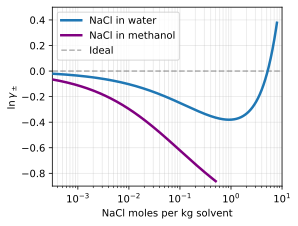

In [2]:

plt.figure(figsize=(4, 3), dpi=150)
plt.axes((0.17,0.16,0.8,0.83))
plt.xscale('log')


# Curves
plt.plot(m_range, ln_gamma_water, linewidth=2.5, label='NaCl in water', zorder=100)
plt.plot(m_range_meoh, ln_gamma_meoh, linewidth=2.5, color='purple', label='NaCl in methanol', zorder=100)

plt.axhline(0, color='black', ls='--', alpha=0.3, label='Ideal')

plt.xlabel(r'NaCl moles per kg solvent')
plt.ylabel(r'$\ln \gamma_\pm$')
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc='upper left', fontsize=10)
plt.xlim(10**-3.5,10)
plt.ylim(-0.9,0.5)

plt.show()